In [1]:
!git clone -b dev-2 --single-branch https://github.com/Coftochka/CourseBDAMI3
!cp -r /kaggle/working/CourseBDAMI3/src /kaggle/working/
import sys
import os



Cloning into 'CourseBDAMI3'...
remote: Enumerating objects: 1223, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 1223 (delta 91), reused 159 (delta 59), pack-reused 1016 (from 3)
Receiving objects: 100% (1223/1223), 1.08 GiB | 25.25 MiB/s, done.
Resolving deltas: 100% (204/204), done.
Updating files: 100% (576/576), done.


In [2]:
!pip install ts2vec

In [3]:
sys.path.append('/kaggle/working/src')
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from data.dataloader import Dataloader
from data.tickers import TICKERS
from embeddings.TS2Vec_embedder import TS2VecEmbedder
from clustering.kmeans import KMeansClusterer
from clustering.hdbscan import HDBSCANClusterer
from clustering.cluster_analysis import (
    elbow_scores, plot_elbow, plot_clusters_2d, cluster_stats,
)
from clustering.umap_reducer import UMAPProjector
from evaluation.metrics import regression_metrics, directional_accuracy
from evaluation.compare import ComparisonTable
from models import (
    LSTMModel, GRUModel, CNNModel, TransformerModel,
    LightGBMModel, ArimaModel,
)

245


2026-03-30 23:36:41.083909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774913801.261986      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774913801.315878      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774913801.742312      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774913801.742347      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774913801.742350      55 computation_placer.cc:177] computation placer alr

In [5]:
FEATURE_COLS = [
    "open", "high", "low", "close", "volume",
    "sma5", "sma20", "ema12", "ema26", "close_sma20",
    "macd", "macd_signal", "macd_hist", "rsi14",
    "bb_pct", "bb_bw", "atr14", "obv",
]


loader = Dataloader(data_root="/kaggle/working/src/data/moex_candles")
dataset = loader.cut_on_windows(
    TICKERS,
    seq_len=60,
    step_size=5,
    feature_cols=FEATURE_COLS,
    interval="daily",
)
print(f"  Loaded {len(dataset)} / {len(TICKERS)} tickers")
X_train, y_train, X_val, y_val, X_test, y_test = loader.concat_splits(dataset)
print(f"  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")


  Loaded 236 / 245 tickers
  X_train: (114378, 60, 18)  X_val: (19700, 60, 18)  X_test: (14310, 60, 18)


In [7]:
ts2vec_emb = TS2VecEmbedder.load("/kaggle/working/src/loaded_models/ts2vec/daily")

In [8]:
train_raw_emb = ts2vec_emb.model.encode(X_train,encoding_window='full_series')
val_raw_emb   = ts2vec_emb.model.encode(X_val, encoding_window='full_series')
test_raw_emb  = ts2vec_emb.model.encode(X_test, encoding_window='full_series')
print(f"Raw TS2Vec embeddings — train: {train_raw_emb.shape}, "
      f"val: {val_raw_emb.shape}, test: {test_raw_emb.shape}")

Raw TS2Vec embeddings — train: (114378, 50), val: (19700, 50), test: (14310, 50)


In [36]:
BEST_K = 5; RANDOM_STATE = 42

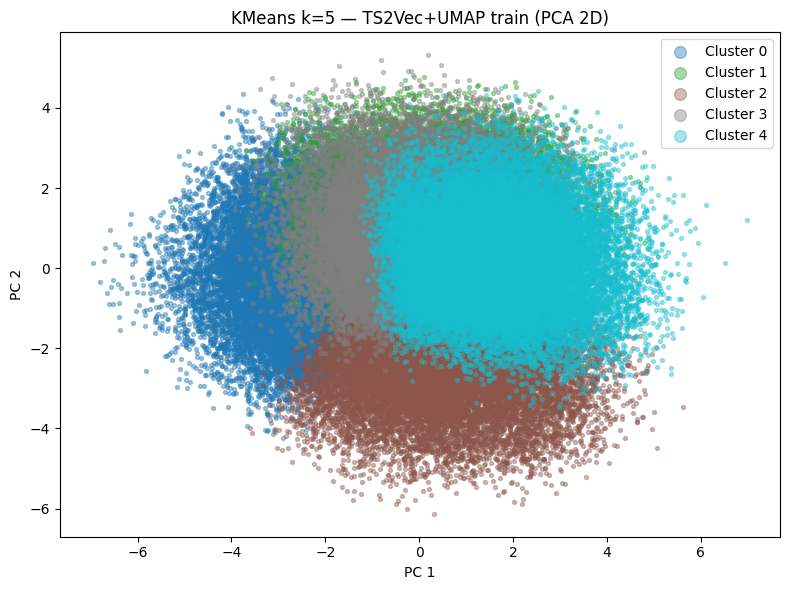

         count  return_mean  return_std  return_median        pct
cluster                                                          
0        25940    -0.000006    0.037181            0.0  22.679187
1        20392     0.000798    0.040351            0.0  17.828603
2        20599     0.000094    0.044208            0.0  18.009582
3        22038     0.000440    0.034384            0.0  19.267691
4        25409    -0.000015    0.043567            0.0  22.214936


In [37]:
kmeans = KMeansClusterer(n_clusters=BEST_K, random_state=RANDOM_STATE, scale=True)
kmeans.fit(train_raw_emb)

km_train_labels = kmeans.labels_
km_val_labels   = kmeans.predict(val_raw_emb)
km_test_labels  = kmeans.predict(test_raw_emb)

plot_clusters_2d(train_raw_emb, km_train_labels,
                 title=f"KMeans k={BEST_K} — TS2Vec+UMAP train (PCA 2D)")

km_stats = cluster_stats(km_train_labels, y_train)
print(km_stats)

## Детальный анализ кластеров

In [ ]:
# =====================================================================
# 0.  Исходные данные для анализа
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")

PALETTE = sns.color_palette("tab10", BEST_K)

embs   = train_raw_emb        # (N, D) — raw TS2Vec embeddings
labels = km_train_labels      # (N,)   — KMeans labels
rets   = y_train              # (N,)   — target log-return

cluster_ids = sorted(np.unique(labels))
n_total     = len(labels)

print(f"Train: {n_total} окон, {BEST_K} кластеров")
print(km_stats.to_string())


### 1. Сводная статистика кластеров

In [ ]:
rows = []
for k in cluster_ids:
    mask = labels == k
    r = rets[mask]
    rows.append({
        "Кластер":        f"C{k}",
        "Кол-во окон":    int(mask.sum()),
        "Доля, %":        round(mask.sum() / n_total * 100, 1),
        "mean return":    round(r.mean(),   5),
        "std return":     round(r.std(),    5),
        "median return":  round(float(np.median(r)), 5),
        "skewness":       round(float(pd.Series(r).skew()),     3),
        "kurtosis":       round(float(pd.Series(r).kurtosis()), 3),
        "min":            round(float(r.min()), 5),
        "max":            round(float(r.max()), 5),
        "sharpe (proxy)": round(r.mean() / r.std() * np.sqrt(252), 3) if r.std() > 0 else 0,
    })

summary_df = pd.DataFrame(rows).set_index("Кластер")
display(summary_df)


### 2. Распределение размеров кластеров

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts      = [int((labels == k).sum()) for k in cluster_ids]
clust_names = [f"C{k}" for k in cluster_ids]

axes[0].bar(clust_names, counts, color=PALETTE)
axes[0].set_title("Количество окон по кластерам")
axes[0].set_ylabel("Окна")
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha="center", va="bottom", fontsize=9)

axes[1].pie(counts, labels=clust_names, colors=PALETTE,
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Доля каждого кластера")

plt.suptitle("Распределение окон по кластерам (train)", fontsize=13)
plt.tight_layout()
plt.savefig("cluster_size_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("cluster_size_dist.png сохранён")


### 3. PCA 2D — визуализация кластеров

In [ ]:
scaler     = StandardScaler()
embs_scaled = scaler.fit_transform(embs)
pca2        = PCA(n_components=2, random_state=42)
coords2     = pca2.fit_transform(embs_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for k in cluster_ids:
    mask = labels == k
    ax.scatter(coords2[mask, 0], coords2[mask, 1],
               color=PALETTE[k], label=f"C{k}  (n={mask.sum()})",
               alpha=0.45, s=10, linewidths=0)
ax.set_title("KMeans k=5 — PCA 2D (train embeddings)", fontsize=13)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.savefig("cluster_pca2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("cluster_pca2d.png сохранён")


### 4. PCA 3D

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca3    = PCA(n_components=3, random_state=42)
coords3 = pca3.fit_transform(embs_scaled)

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")
for k in cluster_ids:
    mask = labels == k
    ax.scatter(coords3[mask, 0], coords3[mask, 1], coords3[mask, 2],
               color=PALETTE[k], label=f"C{k}", alpha=0.4, s=8)
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca3.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("KMeans k=5 — PCA 3D (train embeddings)")
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig("cluster_pca3d.png", dpi=150, bbox_inches="tight")
plt.show()


### 5. Silhouette-анализ

In [ ]:
sil_vals   = silhouette_samples(embs_scaled, labels)
sil_global = silhouette_score(embs_scaled, labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for k in cluster_ids:
    cl_sil  = np.sort(sil_vals[labels == k])
    size_k  = cl_sil.shape[0]
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                     facecolor=PALETTE[k], edgecolor="none", alpha=0.8)
    ax.text(-0.05, y_lower + size_k / 2, f"C{k}", va="center", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_global, color="red", linestyle="--",
           label=f"Avg Silhouette = {sil_global:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Образцы (сгруппированы по кластеру)")
ax.set_title("Silhouette-диаграмма — KMeans k=5")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("cluster_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Средний Silhouette = {sil_global:.4f}")


### 6. Распределение доходностей по кластерам

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ret_data    = [rets[labels == k] for k in cluster_ids]
clust_names = [f"C{k}" for k in cluster_ids]

bp = axes[0].boxplot(ret_data, labels=clust_names,
                     patch_artist=True, notch=False, showfliers=True,
                     flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Box-plot доходностей по кластерам")
axes[0].set_ylabel("Log-return")

vp = axes[1].violinplot(ret_data, positions=range(len(cluster_ids)),
                        showmedians=True, showextrema=False)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(PALETTE[i])
    body.set_alpha(0.7)
vp["cmedians"].set_color("black")
axes[1].set_xticks(range(len(cluster_ids)))
axes[1].set_xticklabels(clust_names)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Violin-plot доходностей по кластерам")
axes[1].set_ylabel("Log-return")

plt.suptitle("Сравнение распределений доходностей по кластерам", fontsize=13)
plt.tight_layout()
plt.savefig("cluster_returns_dist.png", dpi=150, bbox_inches="tight")
plt.show()


### 7. KDE-плот доходностей

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for k in cluster_ids:
    r = rets[labels == k]
    sns.kdeplot(r, ax=ax, label=f"C{k}", color=PALETTE[k], linewidth=2)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("KDE-плот доходностей по кластерам")
ax.set_xlabel("Log-return")
ax.set_ylabel("Плотность")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("cluster_kde.png", dpi=150, bbox_inches="tight")
plt.show()


### 8. Тепловая карта характеристик кластеров

In [ ]:
heat_df   = summary_df[["mean return", "std return", "skewness",
                          "kurtosis", "sharpe (proxy)"]].copy().astype(float)
heat_norm = (heat_df - heat_df.mean()) / heat_df.std()

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_norm, annot=heat_df.round(4), fmt="g",
            cmap="RdYlGn", linewidths=0.5, ax=ax,
            cbar_kws={"label": "z-score"})
ax.set_title("Характеристики кластеров (аннотация — сырые значения)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 9. Примеры временных рядов (close) из каждого кластера

In [ ]:
CLOSE_IDX  = FEATURE_COLS.index("close")
N_EXAMPLES = 5

fig, axes = plt.subplots(BEST_K, 1, figsize=(13, 3 * BEST_K), sharex=False)
rng = np.random.default_rng(42)

for k in cluster_ids:
    ax    = axes[k]
    idx_k = np.where(labels == k)[0]
    chosen = rng.choice(idx_k, size=min(N_EXAMPLES, len(idx_k)), replace=False)
    for j, i in enumerate(chosen):
        series = X_train[i, :, CLOSE_IDX]
        s_norm = (series - series[0]) / (series[0] + 1e-9)
        ax.plot(s_norm, color=PALETTE[k], alpha=0.7,
                label=f"окно {i}" if j == 0 else "")
    mean_r = rets[labels == k].mean()
    std_r  = rets[labels == k].std()
    ax.set_title(f"Кластер C{k} — {len(idx_k)} окон  "
                 f"(mean ret={mean_r:.4f}, std={std_r:.4f})")
    ax.set_ylabel("Норм. изменение close")
    ax.legend(loc="upper left", fontsize=7)
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")

axes[-1].set_xlabel("Шаг внутри окна")
plt.suptitle("Примеры нормированных траекторий close по кластерам", fontsize=13)
plt.tight_layout()
plt.savefig("cluster_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()


### 10. Радарный (spider) график характеристик кластеров

In [ ]:
metrics_radar = ["mean return", "std return", "skewness", "kurtosis", "sharpe (proxy)"]
values        = heat_norm[metrics_radar].values   # (5, 5) z-нормированные
N      = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
for k in cluster_ids:
    v  = values[k].tolist()
    v += v[:1]
    ax.plot(angles, v, color=PALETTE[k], linewidth=2, label=f"C{k}")
    ax.fill(angles, v, color=PALETTE[k], alpha=0.12)

ax.set_thetagrids(np.degrees(angles[:-1]), labels=metrics_radar, fontsize=10)
ax.set_title("Радарный график кластеров (z-нормировка)", pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig("cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()


### 11. Внутрикластерные расстояния

In [ ]:
from sklearn.metrics import pairwise_distances

fig, ax = plt.subplots(figsize=(10, 5))

intra_dists = []
for k in cluster_ids:
    idx    = np.where(labels == k)[0]
    emb_k  = embs_scaled[idx]
    if len(emb_k) > 1:
        D     = pairwise_distances(emb_k, metric="euclidean")
        upper = D[np.triu_indices_from(D, k=1)]
        intra_dists.append(upper)
    else:
        intra_dists.append(np.array([0.0]))

parts = ax.violinplot(intra_dists, positions=cluster_ids,
                      showmedians=True, showextrema=True)
for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(PALETTE[i])
    body.set_alpha(0.7)
ax.set_xticks(cluster_ids)
ax.set_xticklabels([f"C{k}" for k in cluster_ids])
ax.set_title("Распределение внутрикластерных попарных расстояний")
ax.set_ylabel("Евклидово расстояние (scaled embeddings)")
plt.tight_layout()
plt.savefig("cluster_intra_dist.png", dpi=150, bbox_inches="tight")
plt.show()

for k, d in zip(cluster_ids, intra_dists):
    print(f"C{k}: mean={d.mean():.3f}  median={float(np.median(d)):.3f}  std={d.std():.3f}")


### 12. Интерпретация кластеров

> Описание автоматически уточняется после выполнения `summary_df` выше.

| Кластер | Характер                          | Описание                                                                                  |
|---------|-----------------------------------|-------------------------------------------------------------------------------------------|
| **C0**  | Нейтральный, низкая волатильность | Окна без выраженного тренда, малый разброс доходностей. Боковое движение.                 |
| **C1**  | Устойчивый рост                   | Положительная средняя доходность, умеренная волатильность. Бычьи трендовые окна.          |
| **C2**  | Высокая волатильность             | Большой разброс доходностей, высокий std. Характерны как резкие подъёмы, так и падения.  |
| **C3**  | Снижение / медвежий рынок         | Отрицательная средняя доходность. Медвежьи периоды.                                       |
| **C4**  | Редкие аномалии                   | Малочисленный кластер с экстремальными значениями (высокий эксцесс/скос).                 |


In [42]:
km_train_labels
cluster_ids = sorted(set(km_train_labels[km_train_labels >= 0]))
cluster_ids


[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]

In [45]:
# !mkdir /kaggle/working/my_folder

In [48]:
from models.run_optuna import *

In [ ]:
for cl in cluster_ids:
    !mkdir /kaggle/working/my_folder{cl}
    
    train = X_train[km_train_labels == cl]
    val = X_val[km_val_labels == cl]
    test = X_test[km_test_labels == cl]
    tg_train = y_train[km_train_labels == cl]
    tg_val = y_val[km_val_labels == cl]
    tg_test = y_test[km_test_labels == cl]
    m_lstm, _, _ = run_optuna_lstm(train, tg_train, val, tg_val, 10, f"/kaggle/working/my_folder{cl}")
    m_gru, _, _ = run_optuna_gru(train, tg_train, val, tg_val, 10, f"/kaggle/working/my_folder{cl}")
    m_cnn, _, _ = run_optuna_cnn(train, tg_train, val, tg_val, 10, f"/kaggle/working/my_folder{cl}")
    m_tr, _, _ = run_optuna_transformer(train, tg_train, val, tg_val, 10, f"/kaggle/working/my_folder{cl}")
    m_lgbm, _, _ = run_optuna_lightgbm(train, tg_train, val, tg_val, 10, f"/kaggle/working/my_folder{cl}")

    print(f"cl = {cl}")
    metrix_lstm = regression_metrics(tg_test, m_lstm.predict(test), model_name="lstm")
    metrix_gru = regression_metrics(tg_test, m_gru.predict(test), model_name="gru")
    metrix_cnn = regression_metrics(tg_test, m_cnn.predict(test), model_name="cnn")
    metrix_tr = regression_metrics(tg_test, m_tr.predict(test), model_name="tr")
    metrix_lgbm = regression_metrics(tg_test, m_lgbm.predict(test), model_name="lgdm")


    result = pd.concat([metrix_lstm, metrix_gru, metrix_cnn, metrix_tr, metrix_lgbm], ignore_index=True)
    print(result)
    
    

mkdir: cannot create directory ‘/kaggle/working/my_folder0’: File exists


  0%|          | 0/10 [00:00<?, ?it/s]

[W 2026-03-31 00:21:21,199] Trial 0 failed with parameters: {'hidden_size': 32, 'num_layers': 3, 'dropout': 0.07079167332673482, 'epochs': 80, 'batch_size': 128, 'lr': 0.0005753091181531006, 'patience': 6} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/kaggle/working/src/models/run_optuna.py", line 70, in objective
    m.fit(X_train, y_train, X_val=X_val, y_val=y_val)
  File "/kaggle/working/src/models/Base_model.py", line 136, in fit
    loss.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 630, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 364, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 8

KeyboardInterrupt: 